# **Implementación del Algoritmo de Shor para resolver el DLP**

## Resolución de ejemplo de salón para el caso especial del DLP donde $p$ es un primo de Fermat

### Rodrigo Hernández Sacristán

#### Máster en Computación Cuántica, Universidad Internacional de la Rioja (UNIR)

## El objetivo es calcular $x$ tal que $3^x=2\pmod{17}$. 

In [1]:
## LIBRERÍAS NECESARIAS 

import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate 
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram
from IPython.display import display
from qiskit.quantum_info import Operator
from qiskit.circuit.library import QFT
import warnings
import random


Tenemos que $17-1=16=2^4$ luego necesitamos tres registros, los dos primeros de $4$ cúbits cada uno y el tercero de $5$ cúbits. Los definimos:

Por defecto los cúbits están inicializados en el estado $\ket{0}$, por lo tanto, ahora vamos a poner los de los registros A y B en superposición utilizando puertas Hadamard.

Ahora vamos a aplicar el oráculo $U_f$ de la función $f(a,b)=3^{a}2^{-b}\pmod{17}$ en el tercer registro; es decir, el oráculo $U_f$ es de la siguiente forma: 
\begin{equation*}
U_f(\ket{a}\ket{b}\ket{0}^{\otimes (l+1)})=\ket{a}\ket{b}\ket{f(a,b)}
\end{equation*} 

Para ello, vamos a usar que $2^{-1}\pmod{17}=9$ y tendríamos que $f(a,b)=3^{a}9^{b}\pmod{17}$. Calcular el inverso en este caso de juguete es muy sencillo; sin embargo, para un caso con parámetros mucho más grande tampoco habría problema ya que este se encuentra en tiempo polinómico por el Algoritmo de Euclides Extendido.

Antes de pasar a la programación del algoritmo definamos una función que aborte el programa en el caso de que se introduzca un $g$ que no sea generador del grupo cíclico multiplicativo $\mathbb Z_{17}^*$

In [2]:
def es_generador(g, p):
    """Verifica si g es generador de Z_p^*"""
    orden = p - 1
    # Factores primos de 'orden' (para p=17, orden=16=2^4)
    elementos_vistos = set()
    for k in range(1, orden + 1):
        elementos_vistos.add(pow(g, k, p))
    return len(elementos_vistos) == orden

In [3]:
def aplicar_oraculo_matrices(g, h, p, qc, reg_A, reg_B, reg_C, reg_anc=None):
    '''
    Implementa el oráculo cuántico para f(a,b) = g^a * h^(-b) mod p usando matrices de permutación
    '''
    
    num_qubits_reg = len(reg_A)
    q= 2**len(reg_C)  # si  l=5 cúbits pues q=32
    
    # ----------------------------------------------------------------------
    # PASO 1: Inicializar el Registro C en |1> (ya que empezamos multiplicando)
    # ----------------------------------------------------------------------
    # El registro C por defecto está en |00000>, aplicamos una puerta X (NOT)
    # en el primer cúbit para obtener el estado clásico |1> (00001 en binario)
    qc.x(reg_C[0])
    
    # ----------------------------------------------------------------------
    # PASO 2: Calcular las potencias clásicas de las bases mod p
    # ----------------------------------------------------------------------
    # Registro A:
    factores_A = [pow(g, 2**i, p) for i in range(num_qubits_reg)]
    
    # Registro B: potencias del inverso de h. 
    h_inv = pow(h, -1, p)
    factores_B = [pow(h_inv, 2**j, p) for j in range(num_qubits_reg)]
    

    # -------------------------------------------------------------------------------------------------
    # PASO 3: Función interna para crear la matriz de multiplicación modular
    # -------------------------------------------------------------------------------------------------
    def crear_matriz_multiplicacion(k): 
        matriz = np.zeros((q, q)) # Matriz qxq rellena de 0s
        
        for x in range(q):
            if x < p: # Para estados válidos dentro de Z_p^*
                if x == 0:
                    estado_destino = 0
                else:
                    estado_destino = (x * k) % p
            else: 
                # Para  los estados que están fuera del grupo, los mapeamos a sí mismos
                # para mantener la matriz unitaria (identidad en la esquina inferior derecha)
                estado_destino = x
                
            matriz[estado_destino, x] = 1 # Matriz de permutación unitaria
            
        return UnitaryGate(matriz, label=f"x*{k} mod {p}")

    # ----------------------------------------------------------------------
    # PASO 4: Aplicar multiplicaciones controladas por el Registro A
    # ----------------------------------------------------------------------
    for i in range(num_qubits_reg):
        potencia = factores_A[i]
        
        # Optimización: si multiplicar por 1 no cambia el estado, nos saltamos la puerta
        if potencia == 1:
            continue
            
        puerta_mult = crear_matriz_multiplicacion(potencia)
        puerta_controlada = puerta_mult.control(1)
        
        # El cúbit de control es reg_A[i], y actúa sobre todo el reg_C
        qc.append(puerta_controlada, [reg_A[i]] + list(reg_C)) 
        
    # ----------------------------------------------------------------------
    # PASO 5: Aplicar multiplicaciones controladas por el Registro B
    # ----------------------------------------------------------------------
    for j in range(num_qubits_reg):
        potencia = factores_B[j]
        
        if potencia == 1:
            continue
            
        puerta_mult = crear_matriz_multiplicacion(potencia)
        puerta_controlada = puerta_mult.control(1)
        
        # El cúbit de control es reg_B[j], y actúa sobre todo el reg_C
        qc.append(puerta_controlada, [reg_B[j]] + list(reg_C))

# VERSIÓN 1. Disparo Único con Control Dinámico ("Probar Suerte")

In [ ]:
# 1. Definimos los parámetros
g=3
h=2
p=17
p_sub_1=p-1 
l=4
NSHOTS=100

if es_generador(g, p):
    print(f"{g} es generador de Z_{p}^*. Continuando con el resto del circuito...")
    
    # 2. Creamos los registros

    reg_A = QuantumRegister(l, 'A')
    reg_B = QuantumRegister(l, 'B')
    reg_C = QuantumRegister(l+1, 'C_oraculo') 
    #reg_anc = QuantumRegister(num_ancillas_montgomery(p), 'anc')   

    # El bit clásico de decisión: guardará el primer cúbit de reg_A (c_0)
    cl_decision = ClassicalRegister(1, 'c0_impar')

    # Los registros clásicos para guardar el resto si decidimos continuar
    cl_A = ClassicalRegister(l, 'medida_c') # Aquí se guarda el valor completo de 'c'
    cl_B = ClassicalRegister(l, 'medida_d') # Aquí se guarda 'd'

    qc_dinamico = QuantumCircuit(reg_A, reg_B, reg_C, cl_decision, cl_A, cl_B)

    # 3. Inicialización, creación de la superposición con las puertas Hadamard y aplicación del oráculo
    qc_dinamico.h(reg_A)
    qc_dinamico.h(reg_B)
    qc_dinamico.barrier()

    aplicar_oraculo_matrices(g, h, p, qc_dinamico, reg_A, reg_B, reg_C)
    qc_dinamico.barrier()

    # 4. QFT en los registros de control (A y B)
    qc_dinamico.append(QFT(num_qubits=l), reg_A)
    qc_dinamico.append(QFT(num_qubits=l), reg_B)
    qc_dinamico.barrier()

    # Dibujamos el circuito usando el motor de Matplotlib ('mpl')
    
    # Medimos solo el primer cúbit del Registro A (el de las unidades)
    # Este primer cúbit de reg_A representa si el número 'c' que vamos a medir es impar.
    qc_dinamico.measure(reg_A[0], cl_decision)

    # 4. CONDICIÓN: Si ese cúbit es 1 (impar), medimos los registros completos A y B
    with qc_dinamico.if_test((cl_decision, 1)):
        qc_dinamico.measure(reg_A, cl_A)
        qc_dinamico.measure(reg_B, cl_B)

    # Usamos el estilo 'iqp', que es el estándar moderno de IBM 
    fig = qc_dinamico.draw('mpl', style='iqp')

    # Guardamos el dibujo directamente en un archivo png
    fig.savefig('circuito_shor_especial(17).png', bbox_inches='tight',dpi=300)


    # 5. Ejecutamos 1 SOLO SHOT en el simulador
    simulador = AerSimulator()

    # TRANSPILACIÓN: Traducimos el circuito dinámico a las puertas básicas del simulador
    qc_transpilado = transpile(qc_dinamico, backend=simulador)

    # Ahora corremos el circuito transpilado en vez del original
    job = simulador.run(qc_transpilado, shots=1)
    resultado = job.result()
    cuentas = resultado.get_counts()

    lectura = list(cuentas.keys())[0]
    partes = lectura.split()

    # Qiskit nos devuelve: "medida_d medida_c c0_impar"
    bin_d = partes[0] # d en binario
    bin_c = partes[1] # c en binario 
    bit_decision = partes[2] 

    print("=============================================")
    print("===   SIMULACIÓN DINÁMICA (1 SOLO SHOT)   ===")
    print("=============================================")
    print(f"Resultado del primer cúbit de A (c0): {bit_decision}")

    if bit_decision == '1':
        c = int(bin_c, 2)
        d = int(bin_d, 2)
        c_inv = pow(c, -1, 16)
        x = (-d * c_inv) % 16
        print(f"\n =====Buscamos calcular x tal que {g}**x = {h} mod 17====")
        print(f"\n ¡ÉXITO!")
        print(f"   Se ha medido el estado: c = {c}, d = {d}")
        print(f"   Como c es impar, es invertible mod 16.")
        print(f"   El logaritmo discreto calculado es: x = -c**(-1)d = {x}")
        ### Comprobación ###
        print("=============================================")
        print("\n COMPROBACION")
        comp=pow(g,x,17)
        if comp==h:
            print(f"\n{g}**{x}={comp} mod 17 -> EL LOGARITMO DISCRETO HA SIDO CALCULADO CORRECTAMENTE")
        else:
                print(f"\n{g}**{x}={comp} mod 17 -> El logaritmo discreto NO ha sido calculado correctamente")
    else:
        print(f"\n ABORTADO EN TIEMPO REAL.")
        print(f"   El primer cúbit de A ha colapsado en 0 (el número c es par).")
        print(f"   El circuito detuvo las mediciones de d y c para no arrastrar errores.")
        print(f"   Vuelve a ejecutar para probar otro disparo.")
    print("=============================================")

else:
    print(f"{g} NO es generador de Z_{p}^*. Abortando el programa.")
    exit()  # Termina la ejecución del programa

3 es generador de Z_17^*. Continuando con el resto del circuito...


C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_26320\2470316870.py:37: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_dinamico.append(QFT(num_qubits=l), reg_A)
C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_26320\2470316870.py:38: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_dinamico.append(QFT(num_qubits=l), reg_B)


===   SIMULACIÓN DINÁMICA (1 SOLO SHOT)   ===
Resultado del primer cúbit de A (c0): 1

 =====Buscamos calcular x tal que 3**x = 2 mod 17====

 ¡ÉXITO!
   Se ha medido el estado: c = 5, d = 10
   Como c es impar, es invertible mod 16.
   El logaritmo discreto calculado es: x = -c**(-1)d = 14

 COMPROBACION

3**14=2 mod 17 -> EL LOGARITMO DISCRETO HA SIDO CALCULADO CORRECTAMENTE


# VERSIÓN 2. Esquema "*Repeat-Until-Success*'" (Bucle de reintento)

In [5]:
g=3; h=2; p=17; p_sub_1=p-1; l=4; NSHOTS=100

if es_generador(g, p):
    print(f"{g} es generador de Z_{p}^*. Continuando...")

    reg_A = QuantumRegister(l, 'A')
    reg_B = QuantumRegister(l, 'B')
    reg_C = QuantumRegister(l+1, 'C_oraculo')
    cl_decision = ClassicalRegister(1, 'c0_impar')
    cl_A = ClassicalRegister(l, 'medida_c')
    cl_B = ClassicalRegister(l, 'medida_d')

    
    qc_dinamico = QuantumCircuit(reg_A, reg_B, reg_C, cl_decision, cl_A, cl_B)

    qc_dinamico.h(reg_A)
    qc_dinamico.h(reg_B)
    qc_dinamico.barrier()

    aplicar_oraculo_matrices(g, h, p, qc_dinamico, reg_A, reg_B, reg_C)   
    qc_dinamico.barrier()

    qc_dinamico.append(QFT(num_qubits=l), reg_A)   
    qc_dinamico.append(QFT(num_qubits=l), reg_B)
    qc_dinamico.barrier()


    qc_dinamico.measure(reg_A[0], cl_decision)
    with qc_dinamico.if_test((cl_decision, 1)):
        qc_dinamico.measure(reg_A, cl_A)
        qc_dinamico.measure(reg_B, cl_B)

    simulador = AerSimulator()
    qc_transpilado = transpile(qc_dinamico, backend=simulador)
    cuentas = simulador.run(qc_transpilado, shots=NSHOTS).result().get_counts()
    lecturas = []
    
    for lect, veces in cuentas.items():
        lecturas.extend([lect] * veces)
    random.shuffle(lecturas)

    intentos = 0; exito = False; bin_d = bin_c = None
    print("\n" + "="*55)
    print("===   BÚSQUEDA REPEAT-UNTIL-SUCCESS (c impar)   ===")
    print("="*55)
    for lectura in lecturas:
        intentos += 1
        partes = lectura.split()
        bin_d, bin_c, bit_decision = partes[0], partes[1], partes[2]

        if bit_decision == '1':
            print(f"\nIntento #{intentos:2d}  |  c0 = {bit_decision}")
            print(f"  └──  ¡ÉXITO! Se ha medido un c impar (invertible mod {p_sub_1}).")
            exito = True
            break
        else:
            print(f"\nIntento #{intentos:2d}  |  c0 = {bit_decision}")
            print(f"  └──  Descartado: c es par (no invertible mod {p_sub_1}). Siguiente lectura...")
    print("\n" + "="*55)
    if not exito:
        print(f"=== SIN ÉXITO tras {NSHOTS} shots ===")
        print("="*55)
        print(f"No se midió ningún c impar. Sube NSHOTS y vuelve a intentarlo.")
    else:
        c = int(bin_c, 2); d = int(bin_d, 2)
        c_inv = pow(c, -1, p_sub_1)
        x = (-d * c_inv) % p_sub_1
        comp = pow(g, x, p)
        print(f"=== RESULTADO OBTENIDO (lecturas procesadas: {intentos} de {NSHOTS}) ===")
        print("="*55)
        print(f"Ecuación resuelta:  {g}^x ≡ {h} (mod {p})")
        print(f"Pareja medida:      c = {c},  d = {d}")
        print(f"Como c es impar, es invertible mod {p_sub_1}  (c⁻¹ ≡ {c_inv}).")
        print(f"Logaritmo discreto: x = -d·c⁻¹ mod {p_sub_1} = {x}")
        print("-"*55)
        print(" COMPROBACIÓN CLÁSICA")
        if comp == h:
            print(f"  {g}^{x} ≡ {comp} (mod {p})  ->  ¡EL LOGARITMO DISCRETO ES CORRECTO!")
        else:
            print(f"  {g}^{x} ≡ {comp} (mod {p})  ->  El logaritmo discreto NO es correcto.")
        print("="*55)

else:
    print(f"{g} NO es generador de Z_{p}^*. Abortando el programa.")

3 es generador de Z_17^*. Continuando...


C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_26320\3894447132.py:23: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_dinamico.append(QFT(num_qubits=l), reg_A)
C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_26320\3894447132.py:24: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_dinamico.append(QFT(num_qubits=l), reg_B)



===   BÚSQUEDA REPEAT-UNTIL-SUCCESS (c impar)   ===

Intento # 1  |  c0 = 0
  └──  Descartado: c es par (no invertible mod 16). Siguiente lectura...

Intento # 2  |  c0 = 1
  └──  ¡ÉXITO! Se ha medido un c impar (invertible mod 16).

=== RESULTADO OBTENIDO (lecturas procesadas: 2 de 100) ===
Ecuación resuelta:  3^x ≡ 2 (mod 17)
Pareja medida:      c = 15,  d = 14
Como c es impar, es invertible mod 16  (c⁻¹ ≡ 15).
Logaritmo discreto: x = -d·c⁻¹ mod 16 = 14
-------------------------------------------------------
 COMPROBACIÓN CLÁSICA
  3^14 ≡ 2 (mod 17)  ->  ¡EL LOGARITMO DISCRETO ES CORRECTO!


# VERSIÓN 3. Análisis Estadístico y Didáctico (*Multi-Shot*)

3 es generador de Z_17^*. Continuando con el resto del circuito...


C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_26320\854157632.py:23: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_estandar.append(QFT(num_qubits=l), reg_A)
C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_26320\854157632.py:24: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_estandar.append(QFT(num_qubits=l), reg_B)


[Simulador] Lanzando 100 disparos...

 ANÁLISIS DE LOS ESTADOS MEDIDOS
Ecuación: 3^x ≡ 2 (mod 17)  |  solución real: x = 14

 |d=14, c= 7>  ->   11 veces ( 11.0%)
    └─ c impar: x = -d·c⁻¹ = 14  ->  3^14 ≡ 2 mod 17  ✔
 |d= 8, c=12>  ->   10 veces ( 10.0%)
    └─ c par: no invertible mod 16, medida descartada.
 |d= 6, c= 3>  ->    9 veces (  9.0%)
    └─ c impar: x = -d·c⁻¹ = 14  ->  3^14 ≡ 2 mod 17  ✔
 |d=12, c=14>  ->    7 veces (  7.0%)
    └─ c par: no invertible mod 16, medida descartada.
 |d= 6, c=11>  ->    7 veces (  7.0%)
    └─ c impar: x = -d·c⁻¹ = 14  ->  3^14 ≡ 2 mod 17  ✔
 |d= 4, c= 2>  ->    7 veces (  7.0%)
    └─ c par: no invertible mod 16, medida descartada.
 |d= 2, c= 1>  ->    6 veces (  6.0%)
    └─ c impar: x = -d·c⁻¹ = 14  ->  3^14 ≡ 2 mod 17  ✔
 |d=12, c= 6>  ->    6 veces (  6.0%)
    └─ c par: no invertible mod 16, medida descartada.
 |d= 2, c= 9>  ->    6 veces (  6.0%)
    └─ c impar: x = -d·c⁻¹ = 14  ->  3^14 ≡ 2 mod 17  ✔
 |d=10, c= 5>  ->    6 veces (  6

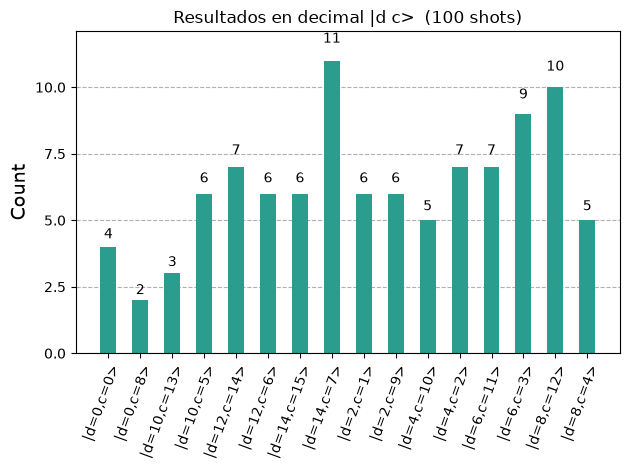


 2. HISTOGRAMA DE VIABILIDAD (c par/impar):


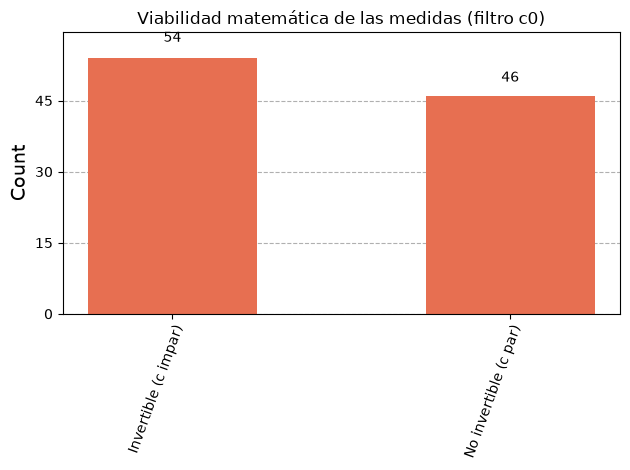

In [7]:
# ==============================================================================
# CIRCUITO ESTÁNDAR PARA HISTOGRAMAS (sin control dinámico)
# ==============================================================================
g = 3; h = 2; p = 17; p_sub_1 = p - 1; l = 4; NSHOTS = 100

if es_generador(g, p):
    print(f"{g} es generador de Z_{p}^*. Continuando con el resto del circuito...")

    reg_A = QuantumRegister(l, 'A')
    reg_B = QuantumRegister(l, 'B')
    reg_C = QuantumRegister(l+1, 'C_oraculo')
    cl_A_est = ClassicalRegister(l, 'c')
    cl_B_est = ClassicalRegister(l, 'd')

   
    qc_estandar = QuantumCircuit(reg_A, reg_B, reg_C, cl_A_est, cl_B_est)

    qc_estandar.h(reg_A)
    qc_estandar.h(reg_B)
    qc_estandar.barrier()
    aplicar_oraculo_matrices(g, h, p, qc_estandar, reg_A, reg_B, reg_C)
    qc_estandar.barrier()
    qc_estandar.append(QFT(num_qubits=l), reg_A)
    qc_estandar.append(QFT(num_qubits=l), reg_B)
    qc_estandar.barrier()
    qc_estandar.measure(reg_A, cl_A_est)
    qc_estandar.measure(reg_B, cl_B_est)

    # ==========================================================================
    # SIMULACIÓN
    # ==========================================================================
    print(f"[Simulador] Lanzando {NSHOTS} disparos...")
    simulador = AerSimulator()
    qc_est_transpilado = transpile(qc_estandar, backend=simulador)
    cuentas_est = simulador.run(qc_est_transpilado, shots=NSHOTS).result().get_counts()

    # ==========================================================================
    # TRADUCCIÓN Y AGRUPACIÓN CLÁSICA DE DATOS
    # ==========================================================================
    x_real = 14  # solución clásica de 3^x = 2 mod 17

    cuentas_decimal = {}                                                        # histograma 1
    cuentas_paridad = {"Invertible (c impar)": 0, "No invertible (c par)": 0}   # histograma 2 

    for lectura, frecuencia in cuentas_est.items():
        bin_d, bin_c = lectura.split()
        d = int(bin_d, 2)
        c = int(bin_c, 2)

        # Histograma 1: etiqueta decimal |d, c>
        cuentas_decimal[f"|d={d},c={c}>"] = frecuencia

        # Histograma 2: paridad de c (viabilidad)
        if c % 2 != 0:
            cuentas_paridad["Invertible (c impar)"] += frecuencia
        else:
            cuentas_paridad["No invertible (c par)"] += frecuencia


    # ==========================================================================
    # GENERACIÓN DE LOS TRES GRÁFICOS
    # ==========================================================================
    fig_hist_dec = plot_histogram(
        cuentas_decimal,
        title=f"Resultados en decimal |d c>  ({NSHOTS} shots)",
        color="#2a9d8f"
    )
    fig_hist_dec.savefig('histograma_shor_especial_decimal(17).png', bbox_inches='tight')

    fig_paridad = plot_histogram(
        cuentas_paridad,
        title="Viabilidad matemática de las medidas (filtro c0)",
        color=["#e76f51", "#45789d"]
    )
    fig_paridad.savefig('histograma_shor_especial_paridad(17).png', bbox_inches='tight')


    # ==========================================================================
    # ANÁLISIS DIDÁCTICO
    # ==========================================================================
    print("\n" + "="*75)
    print(" ANÁLISIS DE LOS ESTADOS MEDIDOS")
    print("="*75)
    print(f"Ecuación: {g}^x ≡ {h} (mod {p})  |  solución real: x = {x_real}\n")

    for lectura, frecuencia in sorted(cuentas_est.items(), key=lambda it: it[1], reverse=True):
        bin_d, bin_c = lectura.split()
        d = int(bin_d, 2); c = int(bin_c, 2)
        pct = 100 * frecuencia / NSHOTS
        print(f" |d={d:2d}, c={c:2d}>  ->  {frecuencia:3d} veces ({pct:5.1f}%)")
        if c % 2 != 0:
            c_inv = pow(c, -1, p_sub_1)
            x = (-d * c_inv) % p_sub_1
            ok = pow(g, x, p) == h
            print(f"    └─ c impar: x = -d·c⁻¹ = {x}  ->  {g}^{x} ≡ {pow(g,x,p)} mod {p}  {'✔' if ok else '�’'}")
        else:
            print(f"    └─ c par: no invertible mod {p_sub_1}, medida descartada.")
    print("="*75)

    print("\n 1. HISTOGRAMA COMPLETO EN DECIMAL:");     display(fig_hist_dec)
    print("\n 2. HISTOGRAMA DE VIABILIDAD (c par/impar):"); display(fig_paridad)

else:
    print(f"{g} NO es generador de Z_{p}^*. Abortando el programa.")